<a href="https://colab.research.google.com/github/Ariqueeezz/Enterprise-Brand-Sentiment-and-Campaign-Analytics-Pipeline/blob/epic%2FEBSCAP-1/EBSCAP_1_EBSCAP_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EBSCAP-3: Download dan standardisasi dataset skala besar**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
output_dir = '/content/drive/MyDrive/EBSCAP/data/raw'
os.makedirs(output_dir, exist_ok=True)

Mounted at /content/drive


In [2]:
import requests
from tqdm import tqdm

categories = "Electronics"
base_url = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories"

def download_file(url, dest_path):
    response = requests.get(url, stream=True)
    response.raise_for_status()
    total_size = int(response.headers.get('content-length', 0))

    with open(dest_path, 'wb') as f, tqdm(
        desc=os.path.basename(dest_path),
        total=total_size,
        unit='iB',
        unit_scale=True,
        unit_divisor=1024,
    ) as bar:
        for chunk in response.iter_content(chunk_size=8192):
            size = f.write(chunk)
            bar.update(size)

    url = f"{base_url}/{categories}.jsonl.gz"
    dest = os.path.join(output_dir, f"{categories}.jsonl.gz")
    if os.path.exists(dest):
        print(f"Skip {categories}, sudah ada.")
    print(f"Downloading {categories}...")
    download_file(url, dest)

In [3]:
total_bytes = 0
path = os.path.join(output_dir, f"{categories}.jsonl.gz")
size = os.path.getsize(path)
total_bytes += size
print(f"{categories}: {size / (1024**3):.2f} GB")

print(f"\nTotal: {total_bytes / (1024**3):.2f} GB")

Electronics: 6.03 GB

Total: 6.03 GB


In [4]:
import json
import gzip

sample_file = os.path.join(output_dir, f"{categories}.jsonl.gz")
with gzip.open(sample_file, 'rt', encoding='utf-8') as f:
    for i, line in enumerate(f):
        print(json.loads(line))
        if i >= 2:
            break

{'rating': 3.0, 'title': 'Smells like gasoline! Going back!', 'text': 'First & most offensive: they reek of gasoline so if you are sensitive/allergic to petroleum products like I am you will want to pass on these.  Second: the phone adapter is useless as-is. Mine was not drilled far enough to be able to tighten it into place for my iPhone 12 max. It just slipped & slid all over. Stupid me putting the adapter together first without picking up the binoculars to smell them bc I wasted 15 minutes trying to figure out how to put the adapter together bc it does not come with instructions!  I had to come back here to the website which was a total pain. Third: the tripod is also useless. I would not trust the iOS to hold my $1600 phone nor even a Mattel Barbie for that matter. It’s just inefficient for the job imo.  Third: in order to try to give an honest review I did don gloves & eyewear to check the binoculars out.  They seemed average except for mine seemed to be missing about 10% of the f

# **EBSCAP-4: Setup local/cloud PySpark session dan sinkronisasi skema**

In [5]:
!pip install pyspark -q

In [6]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("BrandSentimentPipeline-EPIC1")
    .config("spark.driver.memory", "8g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark

In [7]:
raw_path = "/content/drive/MyDrive/EBSCAP/data/raw/Electronics.jsonl.gz"

df_raw = spark.read.json(raw_path)
df_raw.printSchema()

root
 |-- asin: string (nullable = true)
 |-- helpful_vote: long (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- attachment_type: string (nullable = true)
 |    |    |-- large_image_url: string (nullable = true)
 |    |    |-- medium_image_url: string (nullable = true)
 |    |    |-- small_image_url: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- rating: double (nullable = true)
 |-- text: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- title: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- verified_purchase: boolean (nullable = true)



In [8]:
from pyspark.sql.types import (
    StructType, StructField, StringType, DoubleType,
    BooleanType, LongType, ArrayType
)

review_schema = StructType([
    StructField("rating", DoubleType(), True),
    StructField("title", StringType(), True),
    StructField("text", StringType(), True),
    StructField("images", ArrayType(StringType()), True),
    StructField("asin", StringType(), True),
    StructField("parent_asin", StringType(), True),
    StructField("user_id", StringType(), True),
    StructField("timestamp", LongType(), True),
    StructField("verified_purchase", BooleanType(), True),
    StructField("helpful_vote", LongType(), True),
])

df = spark.read.schema(review_schema).json(raw_path)
df.printSchema()

root
 |-- rating: double (nullable = true)
 |-- title: string (nullable = true)
 |-- text: string (nullable = true)
 |-- images: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- asin: string (nullable = true)
 |-- parent_asin: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- timestamp: long (nullable = true)
 |-- verified_purchase: boolean (nullable = true)
 |-- helpful_vote: long (nullable = true)



In [9]:
df.show(5, truncate=50)

+------+-------------------------------------------+--------------------------------------------------+--------------------------------------------------+----------+-----------+----------------------------+-------------+-----------------+------------+
|rating|                                      title|                                              text|                                            images|      asin|parent_asin|                     user_id|    timestamp|verified_purchase|helpful_vote|
+------+-------------------------------------------+--------------------------------------------------+--------------------------------------------------+----------+-----------+----------------------------+-------------+-----------------+------------+
|   3.0|          Smells like gasoline! Going back!|First & most offensive: they reek of gasoline s...|[{"small_image_url": "https://m.media-amazon.co...|B083NRGZMM| B083NRGZMM|AFKZENTNBQ7A7V7UXW5JJI6UGRYQ|1658185117948|             true|      

In [10]:
print(f"Total rows: {df.count():,}")
print(f"Total columns: {len(df.columns)}")

Total rows: 43,886,944
Total columns: 10


In [11]:
df.cache()
df.count()

43886944

# **EBSCAP-5: Lakukan Exploratory Data Analysis (EDA) terdistribusi menggunakan Spark SQL**

## Distribusi Rating per-Review

In [ ]:
df.createOrReplaceTempView("reviews")
rating_dist = spark.sql("""
    SELECT
        rating,
        COUNT(*) AS jumlah_review,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS persentase
    FROM reviews
    GROUP BY rating
    ORDER BY rating
""")
rating_dist.show()

+------+-------------+----------+
|rating|jumlah_review|persentase|
+------+-------------+----------+
|   0.0|            2|      0.00|
|   1.0|      5358800|     12.21|
|   2.0|      2257604|      5.14|
|   3.0|      2883065|      6.57|
|   4.0|      5557725|     12.66|
|   5.0|     27829748|     63.41|
+------+-------------+----------+



## Mendeteksi Missing Values

In [ ]:
from pyspark.sql.functions import col, sum as spark_sum, when

null_counts = df.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df.columns
])
null_counts.show(truncate=False)

+------+-----+----+------+----+-----------+-------+---------+-----------------+------------+
|rating|title|text|images|asin|parent_asin|user_id|timestamp|verified_purchase|helpful_vote|
+------+-----+----+------+----+-----------+-------+---------+-----------------+------------+
|0     |0    |0   |0     |0   |0          |0      |0        |0                |0           |
+------+-----+----+------+----+-----------+-------+---------+-----------------+------------+



## Ringkasan data 'text' atau ulasan pengguna keseluruhan review

In [ ]:
from pyspark.sql.functions import length, split, size

df_with_wordcount = df.withColumn(
    "word_count", size(split(col("text"), " "))
)
df_with_wordcount.createOrReplaceTempView("reviews_wc")

word_stats = spark.sql("""
    SELECT
        MIN(word_count) AS min_kata,
        MAX(word_count) AS max_kata,
        ROUND(AVG(word_count), 1) AS rata_rata_kata,
        PERCENTILE_APPROX(word_count, 0.5) AS median_kata
    FROM reviews_wc
""")
word_stats.show()

+--------+--------+--------------+-----------+
|min_kata|max_kata|rata_rata_kata|median_kata|
+--------+--------+--------------+-----------+
|       1|    6568|          45.3|         23|
+--------+--------+--------------+-----------+



In [ ]:
word_by_rating = spark.sql("""
    SELECT
        rating,
        ROUND(AVG(word_count), 1) AS rata_rata_kata,
        COUNT(*) AS jumlah_review
    FROM reviews_wc
    GROUP BY rating
    ORDER BY rating
""")
word_by_rating.show()

+------+--------------+-------------+
|rating|rata_rata_kata|jumlah_review|
+------+--------------+-------------+
|   0.0|          10.5|            2|
|   1.0|          51.0|      5358800|
|   2.0|          66.4|      2257604|
|   3.0|          65.6|      2883065|
|   4.0|          62.5|      5557725|
|   5.0|          37.0|     27829748|
+------+--------------+-------------+



## Distribusi pengguna yang ter-verifikasi membeli produk yang di review

In [ ]:
spark.sql("""
    SELECT verified_purchase, COUNT(*) AS jumlah
    FROM reviews
    GROUP BY verified_purchase
""").show()

+-----------------+--------+
|verified_purchase|  jumlah|
+-----------------+--------+
|             true|40546884|
|            false| 3340060|
+-----------------+--------+



## Visualisasi distribusi rating

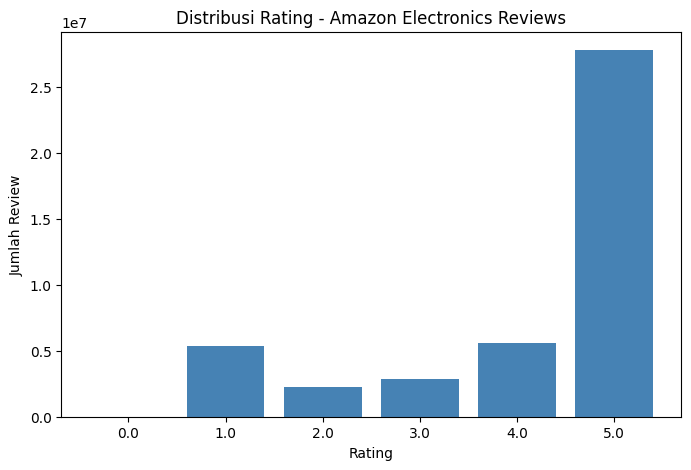

In [ ]:
import matplotlib.pyplot as plt

rating_pd = rating_dist.toPandas()

plt.figure(figsize=(8, 5))
plt.bar(rating_pd["rating"].astype(str), rating_pd["jumlah_review"], color="steelblue")
plt.xlabel("Rating")
plt.ylabel("Jumlah Review")
plt.title("Distribusi Rating - Amazon Electronics Reviews")
plt.show()

# **EBSCAP-7: Implementasi regex cleaner terdistribusi via PySpark UDF**

In [12]:
!pip install emoji -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 14.0 MB/s eta 0:00:00


In [13]:
from pyspark.sql.functions import regexp_replace, trim, lower, col

df_clean = df.withColumn(
    "text_clean",
    regexp_replace(col("text"), r"<[^>]+>", " ")  # remove HTML tags
)

df_clean = df_clean.withColumn(
    "text_clean",
    regexp_replace(col("text_clean"), r"http\S+|www\.\S+", " ")  # remove URL
)

df_clean = df_clean.withColumn(
    "text_clean",
    regexp_replace(col("text_clean"), r"[^a-zA-Z0-9\s.,!?']", " ")  # remove special chars (keep basic punctuation)
)

df_clean = df_clean.withColumn(
    "text_clean",
    trim(regexp_replace(col("text_clean"), r"\s+", " "))  # normalize whitespace
)

In [14]:
import emoji
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType

def remove_emoji(text):
    if text is None:
        return text
    return emoji.replace_emoji(text, replace=' ')

remove_emoji_udf = udf(remove_emoji, StringType())

df_clean = df_clean.withColumn(
    "text_clean",
    remove_emoji_udf(col("text_clean"))
)

In [15]:
df_clean = df_clean.withColumn("text_clean", lower(col("text_clean")))

# Filter baris yang jadi kosong/terlalu pendek setelah cleaning (data quality)
from pyspark.sql.functions import length

df_clean = df_clean.filter(length(trim(col("text_clean"))) > 0)

In [16]:
df_clean.select("text", "text_clean").show(5, truncate=80)

# Bandingkan jumlah baris sebelum & sesudah filter kosong
print(f"Baris sebelum cleaning: {df.count():,}")
# print(f"Baris sesudah cleaning: {df_clean.count():,}")

+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                            text|                                                                      text_clean|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|First & most offensive: they reek of gasoline so if you are sensitive/allergi...|first most offensive they reek of gasoline so if you are sensitive allergic t...|
|These didn’t work. Idk if they were damaged in shipping or what, but the lens...|these didn t work. idk if they were damaged in shipping or what, but the lens...|
|I love these. They even come with a carry case and several sizes of ear bud i...|i love these. they even come with a carry case and several sizes of ear bud i...|
|I was searching

In [17]:
df_clean.cache()
df_clean.count()    # trigger cache

43805806

# **EBSCAP-8: Bangun pipeline tokenisasi dan text vectorization (Word2Vec) menggunakan PySpark ML**

In [18]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover

tokenizer = Tokenizer(inputCol="text_clean", outputCol="tokens_raw")
df_tokens = tokenizer.transform(df_clean)

df_tokens.select("text_clean", "tokens_raw").show(3, truncate=80)

+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                      text_clean|                                                                      tokens_raw|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|first most offensive they reek of gasoline so if you are sensitive allergic t...|[first, most, offensive, they, reek, of, gasoline, so, if, you, are, sensitiv...|
|these didn t work. idk if they were damaged in shipping or what, but the lens...|[these, didn, t, work., idk, if, they, were, damaged, in, shipping, or, what,...|
|i love these. they even come with a carry case and several sizes of ear bud i...|[i, love, these., they, even, come, with, a, carry, case, and, several, sizes...|
+---------------

In [19]:
default_stopwords = StopWordsRemover.loadDefaultStopWords("english")
negation_words = {"not", "no", "nor", "never", "none", "neither",
                   "don't", "doesn't", "didn't", "won't", "wouldn't",
                   "can't", "cannot", "isn't", "aren't", "wasn't", "weren't"}

custom_stopwords = [w for w in default_stopwords if w not in negation_words]

remover = StopWordsRemover(
    inputCol="tokens_raw",
    outputCol="tokens_clean",
    stopWords=custom_stopwords
)
df_tokens = remover.transform(df_tokens)

In [20]:
from pyspark.ml.feature import HashingTF, IDF

hashing_tf = HashingTF(inputCol="tokens_clean", outputCol="raw_features", numFeatures=20000)
df_tf = hashing_tf.transform(df_tokens)

idf = IDF(inputCol="raw_features", outputCol="tfidf_features")
idf_model = idf.fit(df_tf)
df_tfidf = idf_model.transform(df_tf)

df_tfidf.select("tokens_clean", "tfidf_features").show(3, truncate=80)

+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                    tokens_clean|                                                                  tfidf_features|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|[first, offensive, reek, gasoline, sensitive, allergic, petroleum, products, ...|(20000,[125,416,504,803,855,1950,1972,2543,2620,2719,2880,2947,2968,3174,3182...|
|[didn, work., idk, damaged, shipping, what,, lenses, loose, something., see, ...|(20000,[2708,2719,3330,4240,5051,5097,5780,6148,9867,10141,10360,11780,13489,...|
|[love, these., even, come, carry, case, several, sizes, ear, bud, inserts., t...|(20000,[236,495,625,785,1302,1687,1901,1972,2645,3155,4110,4473,5780,5843,608...|
+---------------

In [21]:
from pyspark.ml.feature import Word2Vec

word2vec = Word2Vec(
    vectorSize=100,        # dimensi embedding, umum dipakai 100-300
    minCount=5,            # abaikan kata yang muncul <5 kali (noise reduction)
    inputCol="tokens_clean",
    outputCol="w2v_features"
)

word2vec_model = word2vec.fit(df_tokens)
df_w2v = word2vec_model.transform(df_tokens)

df_w2v.select("tokens_clean", "w2v_features").show(3, truncate=80)

ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/socket.py", line 720, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt
ERROR:py4j.clientserver:Exception occurred while shutting down connection
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver

KeyboardInterrupt: 

In [ ]:
word2vec_model.findSynonyms("battery", 5).show()
word2vec_model.findSynonyms("broken", 5).show()

In [ ]:
output_base = "/content/drive/MyDrive/skripsi-project/data/processed"

word2vec_model.save(f"{output_base}/word2vec_model")
idf_model.save(f"{output_base}/idf_model")

df_w2v.select("rating", "text_clean", "tokens_clean", "w2v_features") \
    .write.mode("overwrite").parquet(f"{output_base}/reviews_w2v.parquet")